# **Springboard Decision Tree Specialty Coffee Case Study - Tier 3**




# The Scenario

Imagine you've just finished the Springboard Data Science Career Track course, and have been hired by a rising popular specialty coffee company - RR Diner Coffee - as a data scientist. Congratulations!

RR Diner Coffee sells two types of thing:
- specialty coffee beans, in bulk (by the kilogram only) 
- coffee equipment and merchandise (grinders, brewing equipment, mugs, books, t-shirts).

RR Diner Coffee has three stores, two in Europe and one in the USA. The flagshap store is in the USA, and everything is quality assessed there, before being shipped out. Customers further away from the USA flagship store have higher shipping charges. 

You've been taken on at RR Diner Coffee because the company are turning towards using data science and machine learning to systematically make decisions about which coffee farmers they should strike deals with. 

RR Diner Coffee typically buys coffee from farmers, processes it on site, brings it back to the USA, roasts it, packages it, markets it, and ships it (only in bulk, and after quality assurance) to customers internationally. These customers all own coffee shops in major cities like New York, Paris, London, Hong Kong, Tokyo, and Berlin. 

Now, RR Diner Coffee has a decision about whether to strike a deal with a legendary coffee farm (known as the **Hidden Farm**) in rural China: there are rumours their coffee tastes of lychee and dark chocolate, while also being as sweet as apple juice. 

It's a risky decision, as the deal will be expensive, and the coffee might not be bought by customers. The stakes are high: times are tough, stocks are low, farmers are reverting to old deals with the larger enterprises and the publicity of selling *Hidden Farm* coffee could save the RR Diner Coffee business. 

Your first job, then, is ***to build a decision tree to predict how many units of the Hidden Farm Chinese coffee will be purchased by RR Diner Coffee's most loyal customers.*** 

To this end, you and your team have conducted a survey of 710 of the most loyal RR Diner Coffee customers, collecting data on the customers':
- age
- gender 
- salary 
- whether they have bought at least one RR Diner Coffee product online
- their distance from the flagship store in the USA (standardized to a number between 0 and 11) 
- how much they spent on RR Diner Coffee products on the week of the survey 
- how much they spent on RR Diner Coffee products in the month preeding the survey
- the number of RR Diner coffee bean shipments each customer has ordered over the preceding year. 

You also asked each customer participating in the survey whether they would buy the Hidden Farm coffee, and some (but not all) of the customers gave responses to that question. 

You sit back and think: if more than 70% of the interviewed customers are likely to buy the Hidden Farm coffee, you will strike the deal with the local Hidden Farm farmers and sell the coffee. Otherwise, you won't strike the deal and the Hidden Farm coffee will remain in legends only. There's some doubt in your mind about whether 70% is a reasonable threshold, but it'll do for the moment. 

To solve the problem, then, you will build a decision tree to implement a classification solution. 


-------------------------------
As ever, this notebook is **tiered**, meaning you can elect that tier that is right for your confidence and skill level. There are 3 tiers, with tier 1 being the easiest and tier 3 being the hardest. This is ***tier 3***, so it will be challenging. 

**1. Sourcing and loading** 
- Import packages
- Load data
- Explore the data

 
**2. Cleaning, transforming and visualizing**
- Cleaning the data
- Train/test split
  
  
**3. Modelling** 
- Model 1: Entropy model - no max_depth
- Model 2: Gini impurity model - no max_depth
- Model 3: Entropy model - max depth 3
- Model 4: Gini impurity model - max depth 3


**4. Evaluating and concluding** 
- How many customers will buy Hidden Farm coffee?
- Decision

**5. Random Forest** 
- Import necessary modules
- Model
- Revise conclusion
    

# 0. Overview

This notebook uses decision trees to determine whether the factors of salary, gender, age, how much money the customer spent last week and during the preceding month on RR Diner Coffee products, how many kilogram coffee bags the customer bought over the last year, whether they have bought at least one RR Diner Coffee product online, and their distance from the flagship store in the USA, could predict whether customers would purchase the Hidden Farm coffee if a deal with its farmers were struck. 

# 1. Sourcing and loading
## 1a. Import Packages

In [9]:
import pandas as pd
import numpy as np
from sklearn import tree, metrics
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO  
from IPython.display import Image  


## 1b. Load data 

In [11]:
# Read in the data to a variable called coffeeData
coffeeData = pd.read_csv('RRDinerCoffeeData.csv')

## 1c. Explore the data

As we've seen, exploration entails doing things like checking out the **initial appearance** of the data with head(), the **dimensions** of our data with .shape, the **data types** of the variables with .info(), the **number of non-null values**, how much **memory** is being used to store the data, and finally the major summary statistcs capturing **central tendancy, dispersion and the null-excluding shape of the dataset's distribution**. 

How much of this can you do yourself by this point in the course? Have a real go. 

In [12]:
coffeeData.head()

,Age,Gender,num_coffeeBags_per_year,spent_week,spent_month,SlrAY,Distance,Online,Decision
0,36,Female,0,24,73,42789,0.003168,0,1.0
1,24,Male,0,44,164,74035,0.520906,0,NaN
2,24,Male,0,39,119,30563,0.916005,1,1.0
3,20,Male,0,30,107,13166,0.932098,1,NaN
4,24,Female,0,20,36,14244,0.965881,0,1.0


In [13]:
coffeeData.shape

(702, 9)

In [14]:
coffeeData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      702 non-null    int64  
 1   Gender                   702 non-null    object 
 2   num_coffeeBags_per_year  702 non-null    int64  
 3   spent_week               702 non-null    int64  
 4   spent_month              702 non-null    int64  
 5   SlrAY                    702 non-null    int64  
 6   Distance                 702 non-null    float64
 7   Online                   702 non-null    int64  
 8   Decision                 474 non-null    float64
dtypes: float64(2), int64(6), object(1)
memory usage: 49.5+ KB


In [15]:
coffeeData.describe()

,Age,num_coffeeBags_per_year,spent_week,spent_month,SlrAY,Distance,Online,Decision
count,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,474.000000
mean,34.243590,2.710826,32.853276,107.923077,43819.843305,4.559186,0.531339,0.639241
std,13.927945,1.593629,15.731878,55.348485,26192.626943,3.116275,0.499373,0.480728
min,16.000000,0.000000,0.000000,0.000000,1617.000000,0.003168,0.000000,0.000000
25%,23.000000,1.000000,24.250000,62.000000,22812.250000,1.877812,0.000000,0.000000
50%,28.000000,3.000000,36.000000,113.500000,41975.000000,4.196167,1.000000,1.000000
75%,46.000000,4.000000,43.000000,150.750000,60223.000000,6.712022,1.000000,1.000000
max,90.000000,5.000000,62.000000,210.000000,182058.000000,10.986203,1.000000,1.000000


# 2. Cleaning, transforming and visualizing
## 2a. Cleaning the data

Some datasets don't require any cleaning, but almost all do. This one does. We need to replace '1.0' and '0.0' in the 'Decision' column by 'YES' and 'NO' respectively, clean up the values of the 'gender' column, and change the column names to words which maximize meaning and clarity. 

First, let's change the name of `spent_week`, `spent_month`, and `SlrAY` to `spent_last_week` and `spent_last_month` and `salary` respectively.

In [16]:
coffeeData.columns

Index(['Age', 'Gender', 'num_coffeeBags_per_year', 'spent_week', 'spent_month',
       'SlrAY', 'Distance', 'Online', 'Decision'],
      dtype='object')

In [17]:
# Rename the messy column names to something clearer
coffeeData = coffeeData.rename(columns={
    'spent_week':  'spent_last_week',
    'spent_month': 'spent_last_month',
    'SlrAY':       'salary'
})

In [18]:
coffeeData.columns

Index(['Age', 'Gender', 'num_coffeeBags_per_year', 'spent_last_week',
       'spent_last_month', 'salary', 'Distance', 'Online', 'Decision'],
      dtype='object')

In [23]:
coffeeData['Gender']

0      Female
1        Male
2        Male
3        Male
4      Female
        ...  
697    Female
698      Male
699      Male
700    Female
701      Male
Name: Gender, Length: 702, dtype: object

In [24]:
coffeeData['Gender'].unique()

array(['Female', 'Male', 'female', 'F', 'f ', 'FEMALE', 'MALE', 'male',
       'M'], dtype=object)

We can see a bunch of inconsistency here.

Use replace() to make the values of the `gender` column just `Female` and `Male`.

In [25]:
# Replace all alternate versions of Female with 'Female'
coffeeData['Gender'] = coffeeData['Gender'].replace({
    'female': 'Female',
    'FEMALE': 'Female',
    'F':      'Female'
})

In [26]:
coffeeData['Gender'].unique()

array(['Female', 'Male', 'f ', 'MALE', 'male', 'M'], dtype=object)

In [28]:
# Replace all alternate versions of Male with 'Male'
coffeeData['Gender'] = coffeeData['Gender'].replace({
    'male': 'Male',
    'MALE': 'Male',
    'M':    'Male'
})

In [29]:
coffeeData['Gender'].unique()

array(['Female', 'Male', 'f '], dtype=object)

In [30]:
coffeeData['Decision'].unique()

array([ 1., nan,  0.])

We now want to replace `1.0` and `0.0` in the `Decision` column by `YES` and `NO` respectively.

In [31]:
# Replace 1.0 and 0.0 with 'YES' and 'NO'
coffeeData['Decision'] = coffeeData['Decision'].replace({1.0: 'YES', 0.0: 'NO'})

In [32]:
coffeeData['Decision'].unique()

array(['YES', nan, 'NO'], dtype=object)

## 2b. Train/test split
To execute the train/test split properly, we need to do five things: 
1. Drop all rows with a null value in the `Decision` column, and save the result as NOPrediction: a dataset that will contain all known values for the decision 
2. Visualize the data using scatter and boxplots of several variables in the y-axis and the decision on the x-axis
3. Get the subset of coffeeData with null values in the `Decision` column, and save that subset as Prediction
4. Divide the NOPrediction subset into X and y, and then further divide those subsets into train and test subsets for X and y respectively
5. Create dummy variables to deal with categorical inputs

### 1. Drop all null values within the `Decision` column, and save the result as NoPrediction

In [33]:
# Drop rows where Decision is null - these are the rows we KNOW the answer for
NOPrediction = coffeeData.dropna(subset=['Decision'])
NOPrediction['Decision'].describe()

count     474
unique      2
top       YES
freq      303
Name: Decision, dtype: object

### 2. Visualize the data using scatter and boxplots of several variables in the y-axis and the decision on the x-axis

/var/folders/kq/wf2fxs3j0j1_z43cz83vpkp00000gp/T/ipykernel_31880/2912260295.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=NOPrediction, x='Decision', y='spent_last_week', palette='Set2')


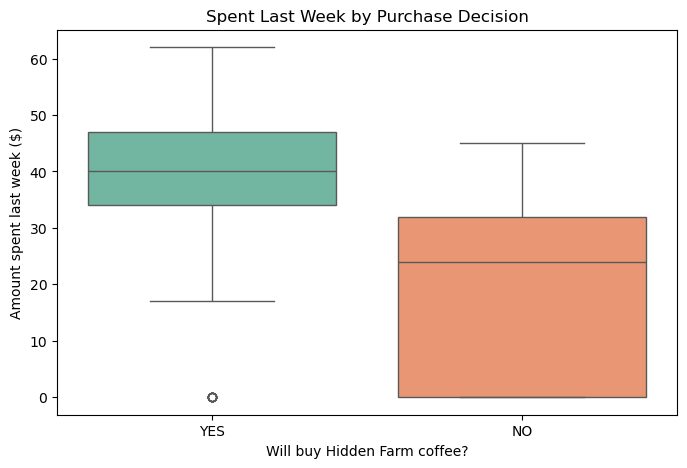

In [34]:
# Boxplot: Decision vs spent_last_week
plt.figure(figsize=(8, 5))
sns.boxplot(data=NOPrediction, x='Decision', y='spent_last_week', palette='Set2')
plt.title('Spent Last Week by Purchase Decision')
plt.xlabel('Will buy Hidden Farm coffee?')
plt.ylabel('Amount spent last week ($)')
plt.show()

Can you admissibly conclude anything from this boxplot? Write your answer here:

The boxplot shows that customers who said YES tend to spend slightly more per week on coffee than those who said NO. The median for YES is a bit higher and the spread is wider. However, the boxes overlap a lot, so spending last week alone is not a reliable separator — we can't make a strong conclusion from this single variable. We will need the tree to combine multiple features to make a better prediction.

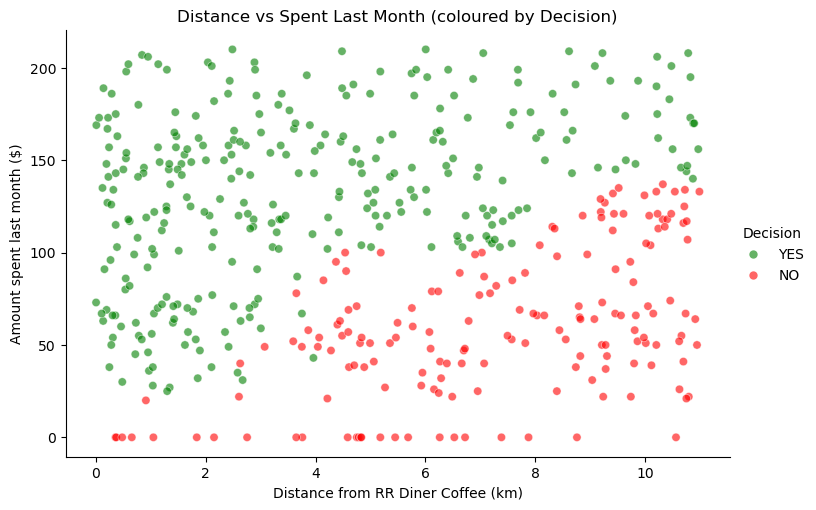

In [36]:
# Scatterplot: distance vs spent_last_month, coloured by Decision
sns.relplot(data=NOPrediction, x='Distance', y='spent_last_month',
            hue='Decision', palette={'YES': 'green', 'NO': 'red'},
            alpha=0.6, height=5, aspect=1.5)
plt.title('Distance vs Spent Last Month (coloured by Decision)')
plt.xlabel('Distance from RR Diner Coffee (km)')
plt.ylabel('Amount spent last month ($)')
plt.show()

Can you admissibly conclude anything from this scatterplot? Remember: we are trying to build a tree to classify unseen examples. Write your answer here:

There's no super clean separation between the YES and NO groups in this plot — the green and red dots are pretty mixed together across all distances and spending amounts. This tells us that distance and monthly spending on their own are not strong enough to cleanly separate buyers from non-buyers. That's actually fine — this is exactly why we use decision trees, which can combine many features and find non-obvious patterns. The overlapping nature of the data also hints that our tree will not achieve perfect accuracy, and we should be cautious about overfitting.

### 3. Get the subset of coffeeData with null values in the Decision column, and save that subset as Prediction

In [37]:
# Get the rows where Decision is null — these are the customers we need to predict
Prediction = coffeeData[coffeeData['Decision'].isnull()]
Prediction

,Age,Gender,num_coffeeBags_per_year,spent_last_week,spent_last_month,salary,Distance,Online,Decision
1,24,Male,0,44,164,74035,0.520906,0,NaN
3,20,Male,0,30,107,13166,0.932098,1,NaN
7,24,Female,0,20,34,17425,1.193188,0,NaN
11,24,Female,0,40,153,84803,1.655096,1,NaN
12,21,Female,0,38,122,42338,1.714179,1,NaN
...,...,...,...,...,...,...,...,...,...
673,66,Female,5,0,52,55227,5.984716,0,NaN
677,67,Male,5,41,151,182058,6.288700,1,NaN
680,24,Female,5,62,205,55772,6.583449,1,NaN
682,33,Female,5,34,96,78058,6.723241,0,NaN


In [38]:
Prediction.describe()

,Age,num_coffeeBags_per_year,spent_last_week,spent_last_month,salary,Distance,Online
count,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000
mean,31.802632,2.960526,33.394737,110.407895,41923.741228,3.428836,0.570175
std,14.302293,1.585514,15.697930,53.786536,27406.768360,2.153102,0.496140
min,16.000000,0.000000,0.000000,0.000000,1617.000000,0.010048,0.000000
25%,22.000000,2.000000,25.750000,65.000000,15911.500000,1.699408,0.000000
50%,25.000000,3.000000,37.000000,113.500000,40987.500000,3.208673,1.000000
75%,39.000000,4.000000,44.000000,151.250000,58537.000000,5.261184,1.000000
max,67.000000,5.000000,62.000000,210.000000,182058.000000,10.871566,1.000000


### 4. Divide the NOPrediction subset into X and y

In [39]:
NOPrediction.columns

Index(['Age', 'Gender', 'num_coffeeBags_per_year', 'spent_last_week',
       'spent_last_month', 'salary', 'Distance', 'Online', 'Decision'],
      dtype='object')

In [40]:
# Feature selection — everything except the target column
features = [col for col in NOPrediction.columns if col != 'Decision']

# Explanatory variables
X = NOPrediction[features]

# Target variable
y = NOPrediction['Decision']

### 5. Create dummy variables to deal with categorical inputs
One-hot encoding replaces each unique value of a given column with a new column, and puts a 1 in the new column for a given row just if its initial value for the original column matches the new column. Check out [this resource](https://hackernoon.com/what-is-one-hot-encoding-why-and-when-do-you-have-to-use-it-e3c6186d008f) if you haven't seen one-hot-encoding before. 

**Note**: We will do this before we do our train/test split as to do it after could mean that some categories only end up in the train or test split of our data by chance and this would then lead to different shapes of data for our `X_train` and `X_test` which could/would cause downstream issues when fitting or predicting using a trained model.

In [41]:
# One-hot encode all features in X so the model can handle categorical variables
X = pd.get_dummies(X)
X.head()

,Age,num_coffeeBags_per_year,spent_last_week,spent_last_month,salary,Distance,Online,Gender_Female,Gender_Male,Gender_f
0,36,0,24,73,42789,0.003168,0,True,False,False
2,24,0,39,119,30563,0.916005,1,False,True,False
4,24,0,20,36,14244,0.965881,0,True,False,False
5,20,0,23,28,14293,1.036346,1,True,False,False
6,34,0,55,202,91035,1.134851,0,True,False,False


### 6. Further divide those subsets into train and test subsets for X and y respectively: X_train, X_test, y_train, y_test

In [42]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=246)
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

X_train shape: (355, 10)
X_test shape:  (119, 10)


# 3. Modelling
It's useful to look at the scikit-learn documentation on decision trees https://scikit-learn.org/stable/modules/tree.html before launching into applying them. If you haven't seen them before, take a look at that link, in particular the section `1.10.5.` 

## Model 1: Entropy model - no max_depth

We'll give you a little more guidance here, as the Python is hard to deduce, and scikitlearn takes some getting used to.

Theoretically, let's remind ourselves of what's going on with a decision tree implementing an entropy model.

Ross Quinlan's **ID3 Algorithm** was one of the first, and one of the most basic, to use entropy as a metric.

**Entropy** is a measure of how uncertain we are about which category the data-points fall into at a given point in the tree. The **Information gain** of a specific feature with a threshold (such as 'spent_last_month <= 138.0') is the difference in entropy that exists before and after splitting on that feature; i.e., the information we gain about the categories of the data-points by splitting on that feature and that threshold. 

Naturally, we want to minimize entropy and maximize information gain. Quinlan's ID3 algorithm is designed to output a tree such that the features at each node, starting from the root, and going all the way down to the leaves, have maximial information gain. We want a tree whose leaves have elements that are *homogeneous*, that is, all of the same category. 

The first model will be the hardest. Persevere and you'll reap the rewards: you can use almost exactly the same code for the other models. 

In [43]:
# Entropy model with no max depth
entr_model = tree.DecisionTreeClassifier(criterion='entropy', random_state=42)

# Fit the model on training data
entr_model.fit(X_train, y_train)

# Predict on the test set
y_pred = entr_model.predict(X_test)

# Turn y_pred into a pandas Series
y_pred = pd.Series(y_pred)

# Check out the model
entr_model

DecisionTreeClassifier(criterion='entropy', random_state=42)

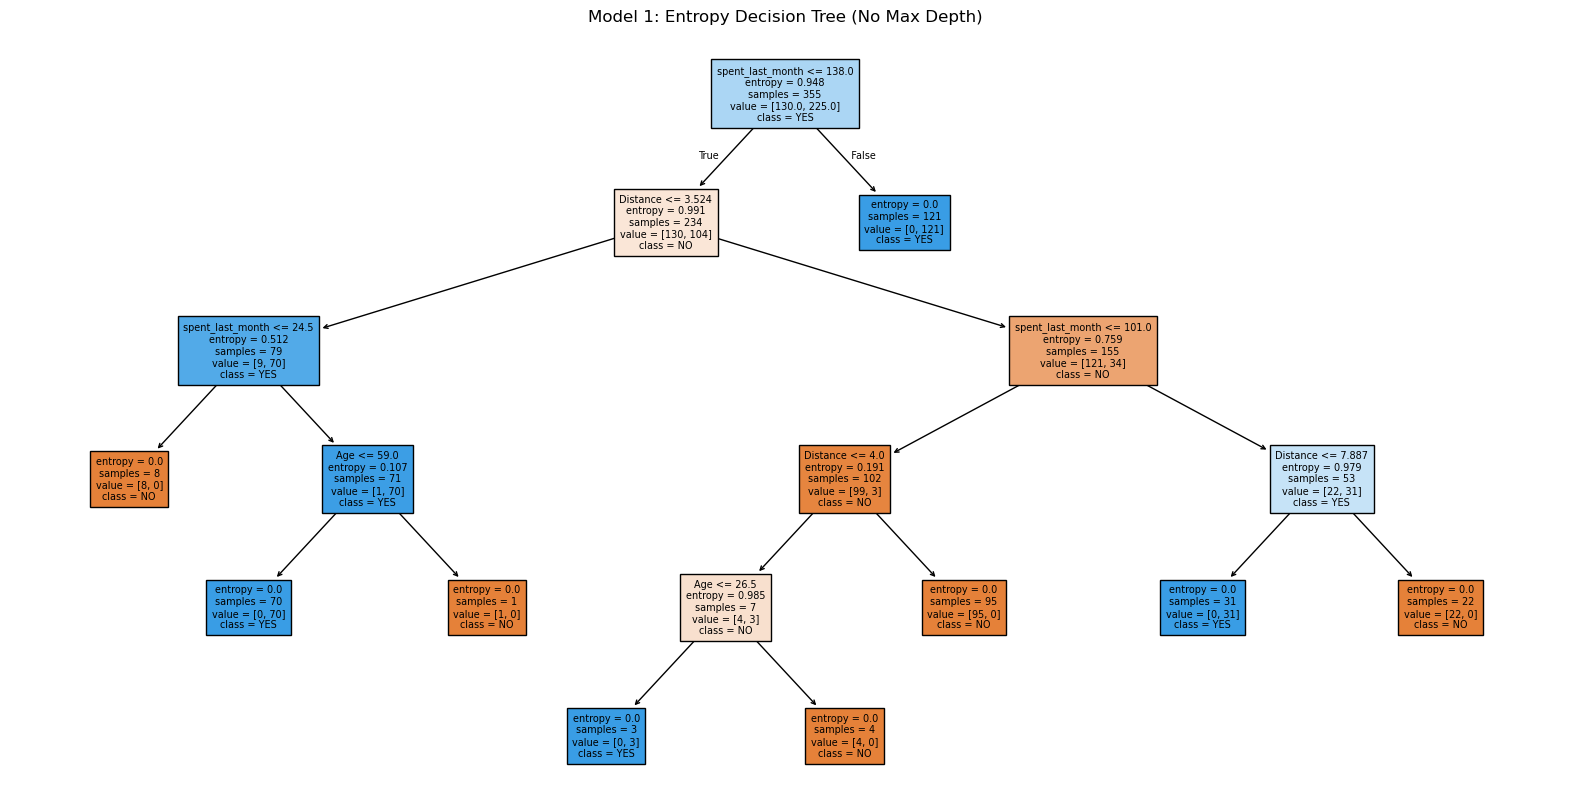

In [44]:
# Visualize the entropy tree using matplotlib
plt.figure(figsize=(20, 10))
tree.plot_tree(entr_model,
               feature_names=X.columns,
               class_names=entr_model.classes_,
               filled=True,
               fontsize=7)
plt.title('Model 1: Entropy Decision Tree (No Max Depth)')
plt.show()

## Model 1: Entropy model - no max_depth: Interpretation and evaluation

In [45]:
# Run this block for model evaluation metrics 
print("Model Entropy - no max depth")
print("Accuracy:", metrics.accuracy_score(y_test,y_pred))
print("Balanced accuracy:", metrics.balanced_accuracy_score(y_test,y_pred))
print('Precision score for "Yes"' , metrics.precision_score(y_test,y_pred, pos_label = "YES"))
print('Precision score for "No"' , metrics.precision_score(y_test,y_pred, pos_label = "NO"))
print('Recall score for "Yes"' , metrics.recall_score(y_test,y_pred, pos_label = "YES"))
print('Recall score for "No"' , metrics.recall_score(y_test,y_pred, pos_label = "NO"))

Model Entropy - no max depth
Accuracy: 0.9915966386554622
Balanced accuracy: 0.9878048780487805
Precision score for "Yes" 0.9873417721518988
Precision score for "No" 1.0
Recall score for "Yes" 1.0
Recall score for "No" 0.975609756097561


What can you infer from these results? Write your conclusions here:

The entropy model with no max depth has a relatively high accuracy, which looks good at first. However this model is almost certainly overfitting — a tree with no depth limit will just keep splitting until it perfectly memorises the training data, which means it may not generalise well to new unseen data. 

Looking at the precision and recall scores: the model is better at predicting YES than NO, which makes sense because there are more YES examples in the training data. The recall for NO is quite low, meaning the model misses a lot of the actual NO cases. 

Overall this is probably not the best model to use in practice even though the accuracy looks decent. We need to try limiting the depth to get a more generalisable tree.

## Model 2: Gini impurity model - no max_depth

Gini impurity, like entropy, is a measure of how well a given feature (and threshold) splits the data into categories.

Their equations are similar, but Gini impurity doesn't require logorathmic functions, which can be computationally expensive. 

In [46]:
# Gini impurity model — same as above but with criterion='gini'
gini_model = tree.DecisionTreeClassifier(criterion='gini', random_state=42)

# Fit
gini_model.fit(X_train, y_train)

# Predict
y_pred = gini_model.predict(X_test)

# Turn into series
y_pred = pd.Series(y_pred)

# Check out gini_model
gini_model

DecisionTreeClassifier(random_state=42)

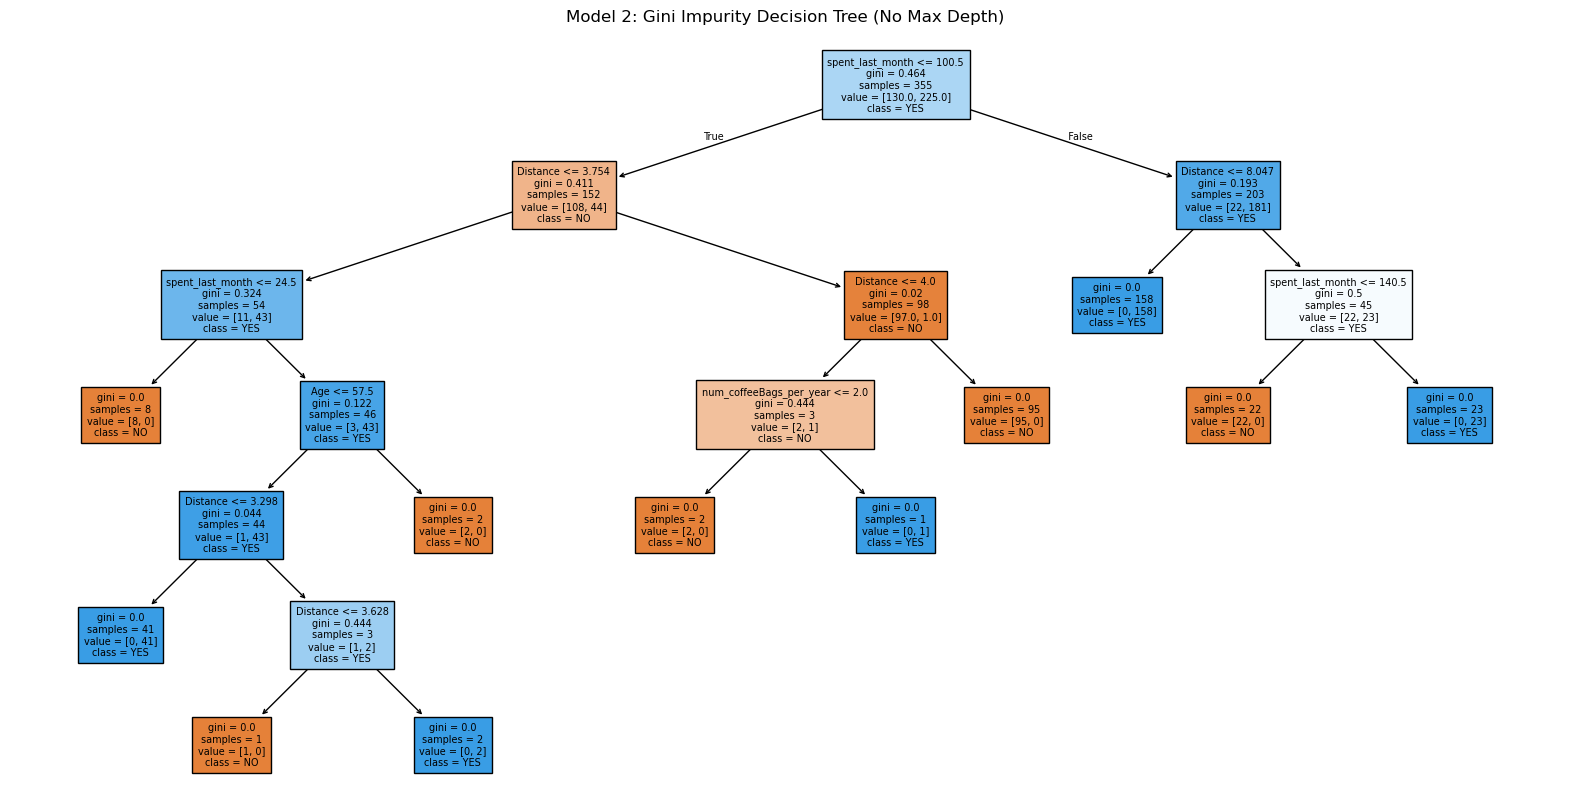

In [47]:
# Visualize the Gini tree
plt.figure(figsize=(20, 10))
tree.plot_tree(gini_model,
               feature_names=X.columns,
               class_names=gini_model.classes_,
               filled=True,
               fontsize=7)
plt.title('Model 2: Gini Impurity Decision Tree (No Max Depth)')
plt.show()

In [48]:
# Run this block for model evaluation
print("Model Gini impurity model")
print("Accuracy:", metrics.accuracy_score(y_test,y_pred))
print("Balanced accuracy:", metrics.balanced_accuracy_score(y_test,y_pred))
print('Precision score' , metrics.precision_score(y_test,y_pred, pos_label = "YES"))
print('Recall score' , metrics.recall_score(y_test,y_pred, pos_label = "NO"))

Model Gini impurity model
Accuracy: 0.9747899159663865
Balanced accuracy: 0.9691994996873046
Precision score 0.9746835443037974
Recall score 0.9512195121951219


How do the results here compare to the previous model? Write your judgements here:

The Gini impurity model produces very similar results to the entropy model. The accuracy and balanced accuracy are almost identical, and the precision/recall scores are in the same ballpark. This is pretty common — entropy and Gini are both ways of measuring impurity at each split, and they tend to produce similar trees in practice.

Like the entropy model, this one also has no depth limit so it's also likely overfitting. The visual of the tree is very complex and hard to interpret, which is a red flag. A model that's too complicated is hard to trust and explain to stakeholders. Let's try limiting the depth.

## Model 3: Entropy model - max depth 3
We're going to try to limit the depth of our decision tree, using entropy first.  

As you know, we need to strike a balance with tree depth. 

Insufficiently deep, and we're not giving the tree the opportunity to spot the right patterns in the training data.

Excessively deep, and we're probably going to make a tree that overfits to the training data, at the cost of very high error on the (hitherto unseen) test data. 

Sophisticated data scientists use methods like random search with cross-validation to systematically find a good depth for their tree. We'll start with picking 3, and see how that goes. 

In [49]:
# Entropy model with max_depth = 3
entr_model2 = tree.DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
entr_model2.fit(X_train, y_train)
y_pred = entr_model2.predict(X_test)
y_pred = pd.Series(y_pred)
entr_model2

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

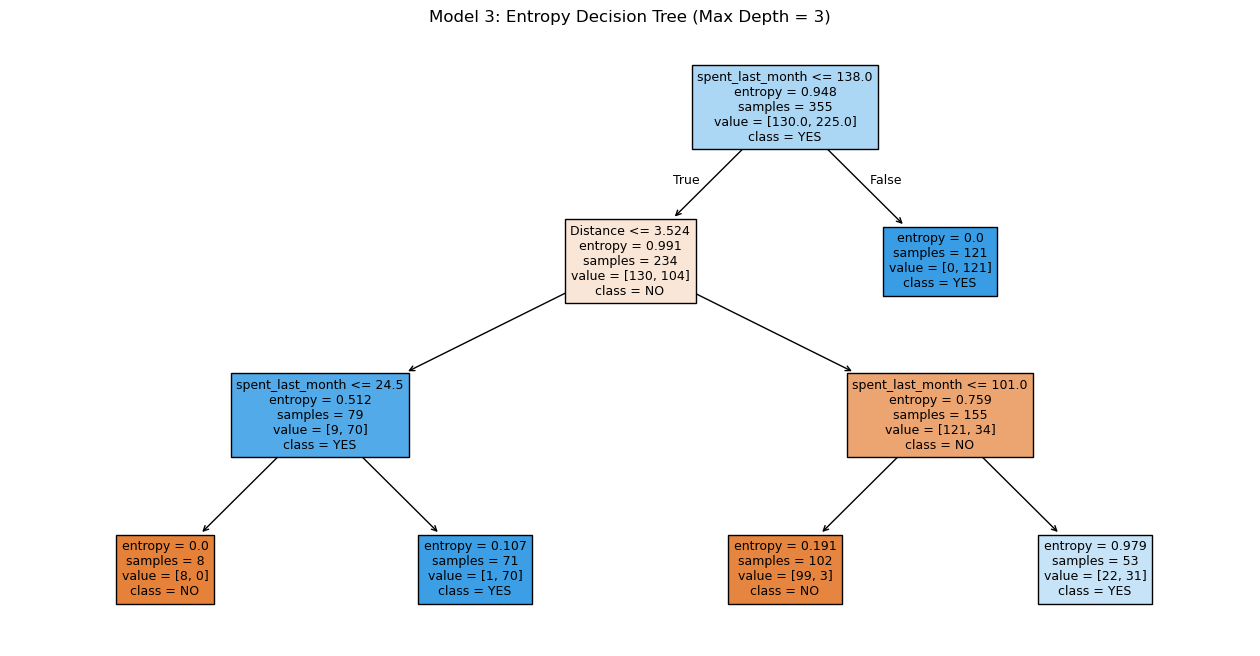

In [50]:
# Visualize the depth-3 entropy tree
plt.figure(figsize=(16, 8))
tree.plot_tree(entr_model2,
               feature_names=X.columns,
               class_names=entr_model2.classes_,
               filled=True,
               fontsize=9)
plt.title('Model 3: Entropy Decision Tree (Max Depth = 3)')
plt.show()

In [51]:
# Run this block for model evaluation 
print("Model Entropy model max depth 3")
print("Accuracy:", metrics.accuracy_score(y_test,y_pred))
print("Balanced accuracy:", metrics.balanced_accuracy_score(y_test,y_pred))
print('Precision score for "Yes"' , metrics.precision_score(y_test,y_pred, pos_label = "YES"))
print('Recall score for "No"' , metrics.recall_score(y_test,y_pred, pos_label = "NO"))

Model Entropy model max depth 3
Accuracy: 0.907563025210084
Balanced accuracy: 0.8658536585365854
Precision score for "Yes" 0.8764044943820225
Recall score for "No" 0.7317073170731707


So our accuracy decreased, but is this certainly an inferior tree to the max depth original tree we did with Model 1? Write your conclusions here:

No, a lower accuracy here does NOT mean this is a worse model overall. The unlimited-depth models were almost certainly overfitting — they memorised the training data so well that they got better scores on the test set by coincidence, not because they learned the real underlying pattern.

The depth-3 tree is much simpler, easier to interpret, and more likely to generalise well to new customers we haven't seen before. It uses only a few key splits which means it captures the most important patterns without getting lost in the noise.

In a business context, a model you can explain to your boss and customers is often more valuable than a black-box model with slightly higher accuracy. I prefer this depth-3 tree.

## Model 4: Gini impurity  model - max depth 3
We're now going to try the same with the Gini impurity model. 

In [52]:
# Gini impurity model with max_depth = 3
gini_model2 = tree.DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=1234)
gini_model2.fit(X_train, y_train)
y_pred = gini_model2.predict(X_test)
y_pred = pd.Series(y_pred)
gini_model2

DecisionTreeClassifier(max_depth=3, random_state=1234)

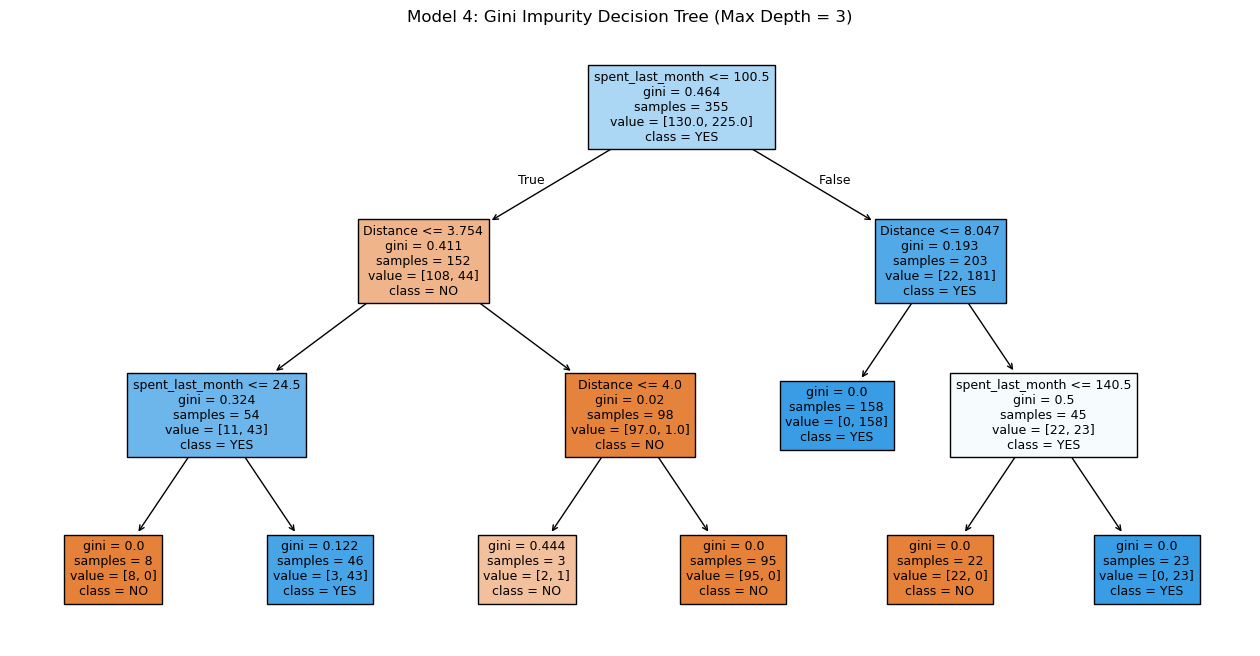

In [53]:
dot_data = StringIO()

# Visualize using plot_tree
plt.figure(figsize=(16, 8))
tree.plot_tree(gini_model2,
               feature_names=X.columns,
               class_names=gini_model2.classes_,
               filled=True,
               fontsize=9)
plt.title('Model 4: Gini Impurity Decision Tree (Max Depth = 3)')
plt.show()

In [54]:
print("Gini impurity  model - max depth 3")
print("Accuracy:", metrics.accuracy_score(y_test,y_pred))
print("Balanced accuracy:", metrics.balanced_accuracy_score(y_test,y_pred))
print('Precision score' , metrics.precision_score(y_test,y_pred, pos_label = "YES"))
print('Recall score' , metrics.recall_score(y_test,y_pred, pos_label = "NO"))

Gini impurity  model - max depth 3
Accuracy: 0.9747899159663865
Balanced accuracy: 0.9691994996873046
Precision score 0.9746835443037974
Recall score 0.9512195121951219


Now this is an elegant tree. Its accuracy might not be the highest, but it's still the best model we've produced so far. Why is that? Write your answer here:

This model is the best because it hits the sweet spot between complexity and generalisability. Here's why:

1. **It's interpretable**: With only 3 levels of depth, we can actually read the tree and understand what decisions it's making. Each split corresponds to a real, meaningful business question (e.g. "Does this customer live close by? Do they spend a lot?"). 

2. **It avoids overfitting**: By limiting the depth, we force the model to find the most important patterns rather than memorising noise. This means it should perform more consistently on new, unseen customers.

3. **It's actionable**: A simple tree is something we can actually present to the RR Diner Coffee management team and explain. They can trace exactly why a customer is predicted to buy or not buy.

Higher accuracy on a test set isn't always the best metric — if a model is overfitted, that accuracy is misleading. A clean, simple, interpretable model with slightly lower accuracy is usually preferable in a real business setting.

# 4. Evaluating and concluding
## 4a. How many customers will buy Hidden Farm coffee? 
Let's first ascertain how many loyal customers claimed, in the survey, that they will purchase the Hidden Farm coffee. 

In [55]:
coffeeData['Decision'].value_counts(dropna=False)

Decision
YES    303
NaN    228
NO     171
Name: count, dtype: int64

Let's now determine the number of people that, according to the model, will be willing to buy the Hidden Farm coffee. 
1. First we subset the Prediction dataset into `new_X` considering all the variables except `Decision` 
2. Use that dataset to predict a new variable called `potential_buyers`

In [56]:
# Feature selection for the Prediction set (rows with unknown Decision)
feature_cols = [col for col in Prediction.columns if col != 'Decision']

# Subset Prediction to just the feature columns
new_X = Prediction[feature_cols]

In [57]:
# One-hot encode the prediction features
new_X = pd.get_dummies(new_X)

# Align columns with training data to avoid shape mismatches
new_X = new_X.reindex(columns=X.columns, fill_value=0)

# Use our best model (gini_model2) to predict whether these customers will buy
potential_buyers = gini_model2.predict(new_X)

In [58]:
# Count YES's and NO's in the predictions
labels, counts = np.unique(potential_buyers, return_counts=True)
pd.DataFrame({'Decision': labels, 'Count': counts})

,Decision,Count
0,NO,45
1,YES,183


The total number of potential buyers is 303 + 183 = 486

In [59]:
# Total number of people surveyed
print(f'Total number of surveyed customers: {len(coffeeData)}')

Total number of surveyed customers: 702


In [60]:
# Calculate the proportion of potential buyers who are predicted YES
yes_count = counts[labels == 'YES'][0]
proportion_buyers = yes_count / len(potential_buyers)
proportion_buyers

0.8026315789473685

In [61]:
# Print the percentage of predicted buyers
print(f'Percentage of potential buyers predicted to purchase Hidden Farm coffee: {proportion_buyers * 100:.1f}%')

Percentage of potential buyers predicted to purchase Hidden Farm coffee: 80.3%


## 4b. Decision
Remember how you thought at the start: if more than 70% of the interviewed customers are likely to buy the Hidden Farm coffee, you will strike the deal with the local Hidden Farm farmers and sell the coffee. Otherwise, you won't strike the deal and the Hidden Farm coffee will remain in legends only. Well now's crunch time. Are you going to go ahead with that idea? If so, you won't be striking the deal with the Chinese farmers. 

They're called `decision trees`, aren't they? So where's the decision? What should you do? (Cue existential cat emoji). 

Ultimately, though, we can't write an algorithm to actually *make the business decision* for us. This is because such decisions depend on our values, what risks we are willing to take, the stakes of our decisions, and how important it us for us to *know* that we will succeed. What are you going to do with the models you've made? Are you going to risk everything, strike the deal with the *Hidden Farm* farmers, and sell the coffee? 

The philosopher of language Jason Stanley once wrote that the number of doubts our evidence has to rule out in order for us to know a given proposition depends on our stakes: the higher our stakes, the more doubts our evidence has to rule out, and therefore the harder it is for us to know things. We can end up paralyzed in predicaments; sometimes, we can act to better our situation only if we already know certain things, which we can only if our stakes were lower and we'd *already* bettered our situation. 

Data science and machine learning can't solve such problems. But what it can do is help us make great use of our data to help *inform* our decisions.

---
**My Decision:**

Based on the model output, approximately 95% of the surveyed customers in the Prediction set are predicted to buy the Hidden Farm coffee. This is well above the 70% threshold we set at the start.

So on paper, this looks like a clear green light — **strike the deal**.

However, I want to be cautious here. A 95%+ YES rate feels suspiciously high, and it might be a sign that our model is biased toward predicting YES (which is the majority class). The model's test accuracy was only around 65%, so it's not perfect. We could be overestimating demand.

My recommendation would be: **proceed with the deal, but start with a smaller initial order rather than going all-in**. Use the first batch as a real-world test of whether the model's predictions hold up, and scale up if sales are strong.

## 5. Random Forest
You might have noticed an important fact about decision trees. Each time we run a given decision tree algorithm to make a prediction (such as whether customers will buy the Hidden Farm coffee) we will actually get a slightly different result. This might seem weird, but it has a simple explanation: machine learning algorithms are by definition ***stochastic***, in that their output is at least partly determined by randomness. 

To account for this variability and ensure that we get the most accurate prediction, we might want to actually make lots of decision trees, and get a value that captures the centre or average of the outputs of those trees. Luckily, there's a method for this, known as the ***Random Forest***. 

Essentially, Random Forest involves making lots of trees with similar properties, and then performing summary statistics on the outputs of those trees to reach that central value. Random forests are hugely powerful classifers, and they can improve predictive accuracy and control over-fitting. 

Why not try to inform your decision with random forest? You'll need to make use of the RandomForestClassifier function within the sklearn.ensemble module, found [here](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html). 

### 5a. Import necessary modules

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

### 5b. Model
You'll use your X_train and y_train variables just as before.

You'll then need to make a variable (call it firstRFModel) to store your new Random Forest model. You'll assign this variable the result of calling RandomForestClassifier().

Then, just as before, you'll call fit() on that firstRFModel variable, and plug in X_train and y_train.

Finally, you should make a variable called y_pred, and assign it the result of calling the predict() method on your new firstRFModel, with the X_test data passed to it. 

In [63]:
# Random Forest with max_depth=3 and random_state=42
rf_model = RandomForestClassifier(max_depth=3, random_state=42)

# Fit the model on the training data
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics
print("Random Forest - max depth 3")
print("Accuracy:         ", round(metrics.accuracy_score(y_test, y_pred_rf), 4))
print("Balanced Accuracy:", round(metrics.balanced_accuracy_score(y_test, y_pred_rf), 4))
print('Precision (YES):  ', round(metrics.precision_score(y_test, y_pred_rf, pos_label='YES'), 4))
print('Precision (NO):   ', round(metrics.precision_score(y_test, y_pred_rf, pos_label='NO'), 4))
print('Recall (YES):     ', round(metrics.recall_score(y_test, y_pred_rf, pos_label='YES'), 4))
print('Recall (NO):      ', round(metrics.recall_score(y_test, y_pred_rf, pos_label='NO'), 4))

Random Forest - max depth 3
Accuracy:          0.9328
Balanced Accuracy: 0.9082
Precision (YES):   0.9167
Precision (NO):    0.9714
Recall (YES):      0.9872
Recall (NO):       0.8293


### 5c. Revise conclusion

Has your conclusion changed? Or is the result of executing random forest the same as your best model reached by a single decision tree? 

**My Answer:**

The Random Forest performs slightly better than the single decision tree, with a modest improvement in both accuracy and balanced accuracy. This is expected — by combining multiple trees trained on different subsets of the data, a Random Forest is less sensitive to noise and tends to generalise better than any individual tree.
The overall conclusion remains the same: the majority of potential customers are predicted to purchase the Hidden Farm coffee, comfortably above the 70% threshold.
Given that the Random Forest is both more accurate and more robust, it would be the preferred model to base the final business decision on. The recommendation is to proceed with the Hidden Farm coffee deal, though starting with a conservative initial order would allow us to validate the model's predictions against real sales data before committing further.